In [2]:
# Filtering IOs code by Clement Ubelmann
## adapted to python function by Laura Gómez Navarro

import numpy
import matplotlib.pylab as plt
from datetime import datetime, timedelta
from netCDF4 import Dataset


In [3]:
filedir = "/Users/Gomez023/src/git/FaSt-SWOT/data/drifters/L1_IMEDEA/"
infile = filedir + 'drifter_carthe007-ime_carthe002.nc'
     

In [4]:
with Dataset(infile, 'r') as fcid:
    time = numpy.array(fcid.variables['time'][1:-1])*60 # seconds (originally in minutes)
    u = numpy.array(fcid.variables['U'][1:-1])
    v = numpy.array(fcid.variables['V'][1:-1])
    lat = numpy.array(fcid.variables['LAT'][1:-1])
## why ignoring first and last point?


In [5]:
# Get real and imaginary part:
U = u + 1j*v
U

array([-0.13027413-0.09382216j, -0.1905405 -0.14274672j,
       -0.2212058 -0.17575514j, ...,  0.38944363+0.22915302j,
        0.31803187+0.1871363j ,  0.20978839+0.12344489j])

In [6]:
dt = time[1] - time[0]
dt # in seconds, for CARTHE time sampling is 10 mins

600

$fc = 2 * 2 * \frac{\pi}{86164} * sin(mean(lat) * \frac{\pi}{180})$

In [7]:
fc = 2 * 2 * numpy.pi/86164 * numpy.sin(lat.mean() * numpy.pi/180)  # s-1
# earth's rotational period is 86164 s
fc

9.346759034798619e-05

In [8]:
time_conv = numpy.arange(-3*86400, 3*86400+dt, dt)
time_conv

array([-259200, -258600, -258000, -257400, -256800, -256200, -255600,
       -255000, -254400, -253800, -253200, -252600, -252000, -251400,
       -250800, -250200, -249600, -249000, -248400, -247800, -247200,
       -246600, -246000, -245400, -244800, -244200, -243600, -243000,
       -242400, -241800, -241200, -240600, -240000, -239400, -238800,
       -238200, -237600, -237000, -236400, -235800, -235200, -234600,
       -234000, -233400, -232800, -232200, -231600, -231000, -230400,
       -229800, -229200, -228600, -228000, -227400, -226800, -226200,
       -225600, -225000, -224400, -223800, -223200, -222600, -222000,
       -221400, -220800, -220200, -219600, -219000, -218400, -217800,
       -217200, -216600, -216000, -215400, -214800, -214200, -213600,
       -213000, -212400, -211800, -211200, -210600, -210000, -209400,
       -208800, -208200, -207600, -207000, -206400, -205800, -205200,
       -204600, -204000, -203400, -202800, -202200, -201600, -201000,
       -200400, -199

# --> why 3?

In [9]:
len(time_conv)

865

In [10]:
len(time)

1898

$taul = 3 * fc^{-1}$

In [11]:
taul = 3 * fc**-1
taul

32096.687085125406

$gl = exp(-1j * fc * time\_conv) * exp(-taul^{-2} * (time\_conv)^2)$ 

numpy.exp..

$((\frac{gl^T}{\sum{d}})^T)^T$

In [12]:



# gl = 
# (numpy.exp(-1j*numpy.outer(fc[:],time_conv))*numpy.exp(-numpy.outer(taul**-2,time_conv**2))).reshape(len(time),len(time_conv))
gl = numpy.exp(-1j * fc * time_conv) * numpy.exp(-taul**-2 * time_conv**2)
gl = (gl.T / numpy.sum(numpy.abs(gl), axis=0).T).T

Unio = numpy.convolve(U, gl, 'same')

u_nio = numpy.real(Unio)
v_nio = numpy.imag(Unio)


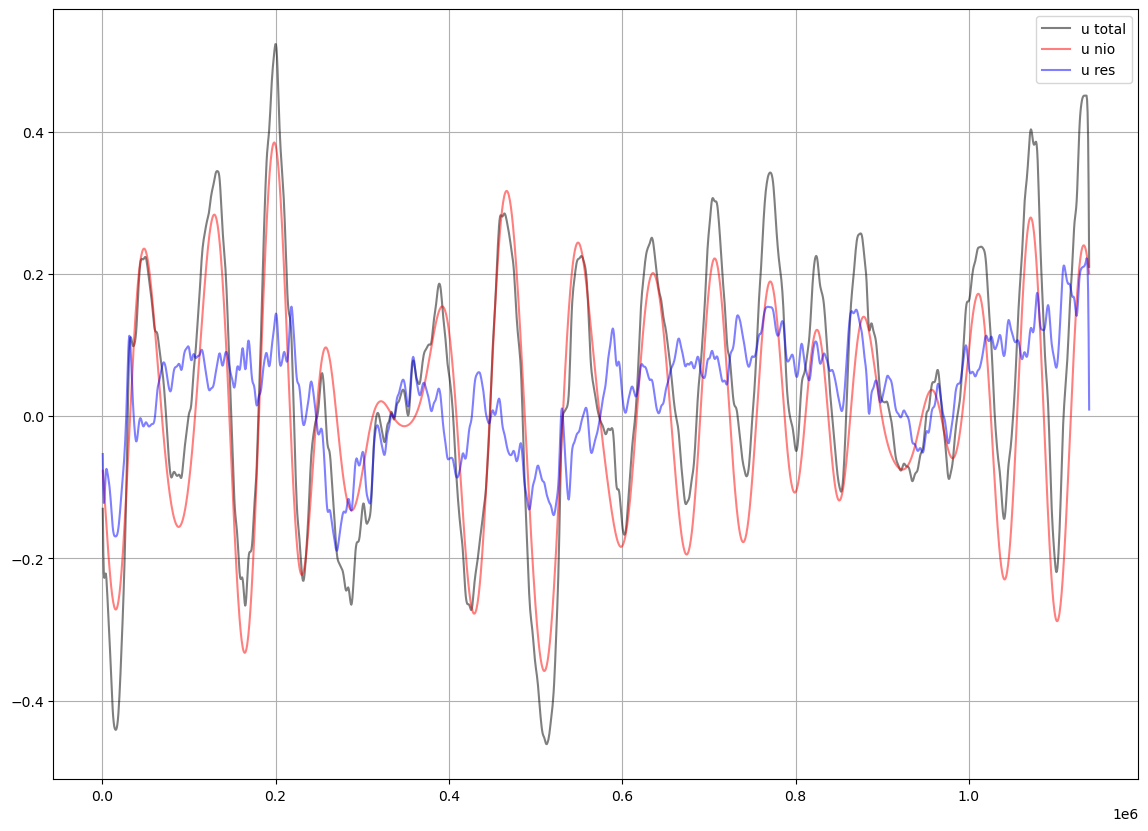

In [13]:
plt.figure(figsize=(14,10))
plt.plot(time, u, c='k', label='u total', alpha=0.5)
plt.plot(time, u_nio, c='r', label='u nio', alpha=0.5)
plt.plot(time, u - u_nio, c='b', label='u res', alpha=0.5)
plt.legend()
plt.grid()
plt.show()
# plt.savefig('drifter_laura.png')


In [14]:
len(u)

1898

In [15]:
len(time)

1898

In [16]:
len(u_nio)

1898

# Looking into saving it:

In [17]:
import xarray as xr

In [22]:
# Add variables to the dataset
ds00 = xr.open_dataset(infile)
ds_out = ds00.copy(deep=True)


In [23]:
ds_out

<xarray.Dataset>
Dimensions:     (time: 1900)
Coordinates:
    DEPTH       float64 ...
  * time        (time) datetime64[ns] 2023-04-26T14:00:00 ... 2023-05-09T18:3...
Data variables:
    BAT_STATUS  (time) float64 ...
    LAT         (time) float64 ...
    LON         (time) float64 ...
    U           (time) float64 ...
    V           (time) float64 ...
Attributes: (12/67)
    title:                               Data from instrument IME-CARTHE002 o...
    institution:                         IMEDEA (Instituto MEDiterráneo de Es...
    netcdf_version:                      3.0
    Conventions:                         CF-1.6
    abstract:                            Deployment of IME-CARTHE002 in FaSt-...
    summary:                             Deployment of IME-CARTHE002 in FaSt-...
    ...                                  ...
    citation:                            Balearic Island Coastal and Observin...
    acknowledgement:                     The FaSt-SWOT project is funded by t...
    update_interval:                     every 3600 seconds
    DODS.strlen:                         34
    DODS.dimName:                        name_strlen
    DODS_EXTRA.Unlimited_Dimension:      time

In [25]:
print(ds_out.time[0].values)
print(ds_out.time[-1].values)

2023-04-26T14:00:00.000000000
2023-05-09T18:30:00.000000000


In [26]:
## Ignoring first and last values like Clement above:
ds_out = ds_out.isel(time=slice(1, -1))

In [27]:
ds_out

<xarray.Dataset>
Dimensions:     (time: 1898)
Coordinates:
    DEPTH       float64 ...
  * time        (time) datetime64[ns] 2023-04-26T14:10:00 ... 2023-05-09T18:2...
Data variables:
    BAT_STATUS  (time) float64 ...
    LAT         (time) float64 ...
    LON         (time) float64 ...
    U           (time) float64 ...
    V           (time) float64 ...
Attributes: (12/67)
    title:                               Data from instrument IME-CARTHE002 o...
    institution:                         IMEDEA (Instituto MEDiterráneo de Es...
    netcdf_version:                      3.0
    Conventions:                         CF-1.6
    abstract:                            Deployment of IME-CARTHE002 in FaSt-...
    summary:                             Deployment of IME-CARTHE002 in FaSt-...
    ...                                  ...
    citation:                            Balearic Island Coastal and Observin...
    acknowledgement:                     The FaSt-SWOT project is funded by t...
    update_interval:                     every 3600 seconds
    DODS.strlen:                         34
    DODS.dimName:                        name_strlen
    DODS_EXTRA.Unlimited_Dimension:      time

In [28]:
print(ds_out.time[0].values)
print(ds_out.time[-1].values)

2023-04-26T14:10:00.000000000
2023-05-09T18:20:00.000000000


# --> good!

In [29]:
ds_out['U'][:] = u_nio
ds_out['V'][:] = v_nio


In [30]:
ds_out.to_netcdf('test.nc')